In [26]:
from result_analysis.utilities.helpers import get_result_dir
from my_helpers.general_helpers import load_json
from result_analysis.utilities.helpers import make_confusion_matrix, plot_confusion_matrix, mean_per_target_tool, make_target_behavior_matrix, plot_target_behavior_matrix, compare_to1_vs_5to1, diff_5to1_minus_1to1, plot_tool_behavior_matrix, make_tool_behavior_matrix

import itertools
import configs
import os

In [2]:
transfer_type = "CLAP_tuned"
base_dir = "../test_result"

In [3]:
behavior = "3-stirring-fast"
data_name = "dataset_discretized.bin"

context_dict = {
    "source_tool_list": [],
    "target_tool_list": [],
    "source_beh_list": [behavior],
    "target_beh_list": [behavior],
    "test_object_list": [],
    "shared_object_list": [],
}

cross_tool_pair = list(itertools.permutations(configs.ALL_TOOL_LIST, 2))
pair_results_bin = {}
for pair in cross_tool_pair:
    context_dict['source_tool_list'] = [pair[0]]
    context_dict['target_tool_list'] = [pair[1]]
    test_result_dir = get_result_dir(base_dir=base_dir, context_dict=context_dict, transfer_type=transfer_type,
                                     modality="audio", data_name=data_name)
    result = load_json(os.path.join(test_result_dir, "results1.json")) 
    pair_results_bin[f"{pair[0]}2{pair[1]}"] = result
    

In [4]:
conf_matrix_bin = make_confusion_matrix(pair_results_bin)
conf_matrix_bin

,metal-scissor,metal-whisk,plastic-knife,plastic-spoon,wooden-chopstick,wooden-fork
metal-scissor,NaN,0.618,0.482,0.346,0.468,0.414
metal-whisk,0.660,NaN,0.514,0.444,0.532,0.568
plastic-knife,0.530,0.580,NaN,0.554,0.550,0.556
plastic-spoon,0.530,0.570,0.512,NaN,0.476,0.548
wooden-chopstick,0.546,0.538,0.462,0.450,NaN,0.448
wooden-fork,0.400,0.562,0.542,0.430,0.452,NaN


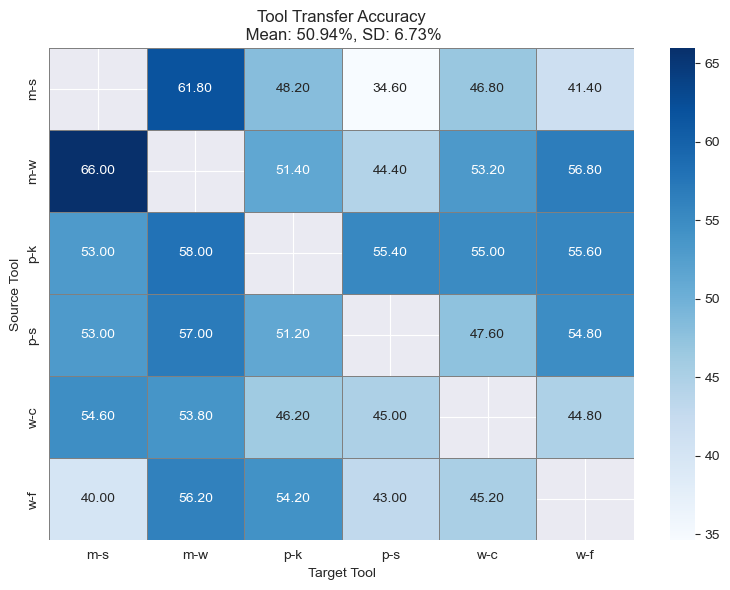

In [5]:
plot_confusion_matrix(conf_matrix=conf_matrix_bin*100)

## audio clap 1to 1

In [6]:
import os

behavior = "3-stirring-fast"
data_name = "audio_20s_clap_emb_all.npz"

context_dict = {
    "source_tool_list": [],
    "target_tool_list": [],
    "source_beh_list": [behavior],
    "target_beh_list": [behavior],
    "test_object_list": [],
    "shared_object_list": [],
}

cross_tool_pair = list(itertools.permutations(configs.ALL_TOOL_LIST, 2))
pair_results_clap = {}
for pair in cross_tool_pair:
    context_dict['source_tool_list'] = [pair[0]]
    context_dict['target_tool_list'] = [pair[1]]
    test_result_dir = get_result_dir(base_dir=base_dir, context_dict=context_dict, transfer_type=transfer_type,
                                     modality="audio", data_name=data_name)
    
    try:
        result = load_json(os.path.join(test_result_dir, "results1.json")) 
        pair_results_clap[f"{pair[0]}2{pair[1]}"] = result
        # print(f"pair_exist: {pair[0]}2{pair[1]}")
    except FileNotFoundError:
        print(f"no result: {test_result_dir}")
        continue  

In [7]:
conf_matrix_clap_to1 = make_confusion_matrix(pair_results_clap)
conf_matrix_clap_to1

,metal-scissor,metal-whisk,plastic-knife,plastic-spoon,wooden-chopstick,wooden-fork
metal-scissor,NaN,0.790,0.598,0.620,0.712,0.680
metal-whisk,0.766,NaN,0.718,0.718,0.760,0.786
plastic-knife,0.786,0.764,NaN,0.812,0.766,0.808
plastic-spoon,0.664,0.750,0.750,NaN,0.746,0.754
wooden-chopstick,0.758,0.810,0.730,0.780,NaN,0.630
wooden-fork,0.732,0.824,0.718,0.796,0.734,NaN


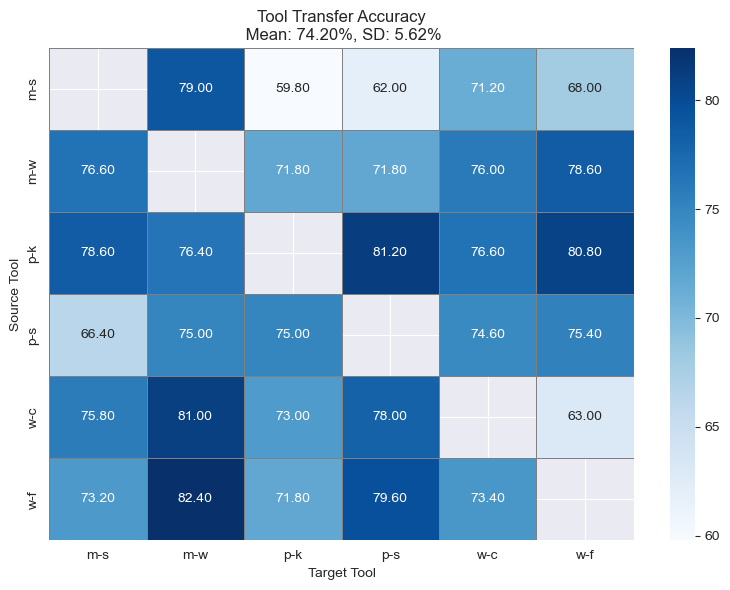

In [8]:
plot_confusion_matrix(conf_matrix=conf_matrix_clap_to1*100)

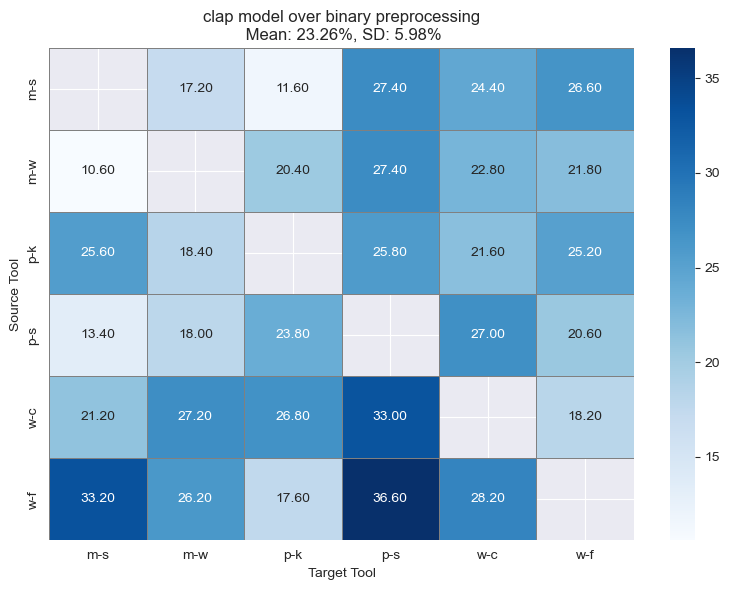

In [9]:
plot_confusion_matrix(conf_matrix=(conf_matrix_clap_to1-conf_matrix_bin)*100, 
                      title="clap model over binary preprocessing")

In [10]:

mean_per_target_tool(conf_matrix=conf_matrix_clap_to1)

metal-scissor       0.7412
metal-whisk         0.7876
plastic-knife       0.7028
plastic-spoon       0.7452
wooden-chopstick    0.7436
wooden-fork         0.7316
dtype: float64

# 5 to 1

## binary - beh3

In [11]:
behavior = "3-stirring-fast"
data_name = "dataset_discretized.bin"

context_dict = {
    "source_tool_list": [],
    "target_tool_list": [],
    "source_beh_list": [],
    "target_beh_list": [],
    "test_object_list": [],
    "shared_object_list": [],
}

pair_results_bin_5to1 = {}
for tgt_t in configs.ALL_TOOL_LIST:
    src_t_list = sorted(t for t in configs.ALL_TOOL_LIST if t != tgt_t)
    context_dict['source_tool_list'] = src_t_list
    context_dict['target_tool_list'] = [tgt_t]
    
    context_dict['source_beh_list'] = [behavior]
    context_dict['target_beh_list'] = [behavior]
    test_result_dir = get_result_dir(base_dir=base_dir, context_dict=context_dict, transfer_type=transfer_type,
                                     modality="audio", data_name=data_name)
    
    try:
        result = load_json(os.path.join(test_result_dir, "results1.json")) 
        pair_results_bin_5to1[f"source_{tgt_t}&{behavior}"] = result
        # print(f"pair_exist: source_{tgt_t}&{beh}")
    except FileNotFoundError:
        print(f"no result: {test_result_dir}")
        continue  

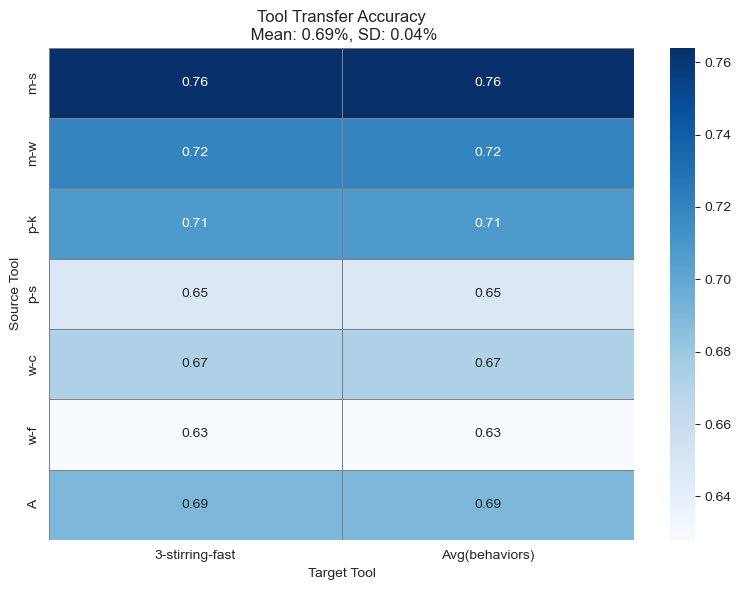

In [12]:


bin_5to1 = make_target_behavior_matrix(pair_results_bin_5to1)
plot_confusion_matrix(bin_5to1)

## clap 5to1, all beh

In [19]:

behavior = "3-stirring-fast"
data_name = "audio_20s_clap_emb_all.npz"

context_dict = {
    "source_tool_list": [],
    "target_tool_list": [],
    "source_beh_list": [],
    "target_beh_list": [],
    "test_object_list": [],
    "shared_object_list": [],
}

pair_results_clap = {}
for tgt_t in configs.ALL_TOOL_LIST:
    src_t_list = sorted(t for t in configs.ALL_TOOL_LIST if t != tgt_t)
    context_dict['source_tool_list'] = src_t_list
    context_dict['target_tool_list'] = [tgt_t]
    for beh in configs.ALL_BEH_LIST:
        context_dict['source_beh_list'] = [beh]
        context_dict['target_beh_list'] = [beh]
        test_result_dir = get_result_dir(base_dir=base_dir, context_dict=context_dict, transfer_type=transfer_type,
                                         modality="audio", data_name=data_name)
    
        try:
            result = load_json(os.path.join(test_result_dir, "results1.json")) 
            pair_results_clap[f"source_{tgt_t}&{beh}"] = result
            # print(f"pair_exist: source_{tgt_t}&{beh}")
        except FileNotFoundError:
            print(f"no result: {test_result_dir}")
            continue  

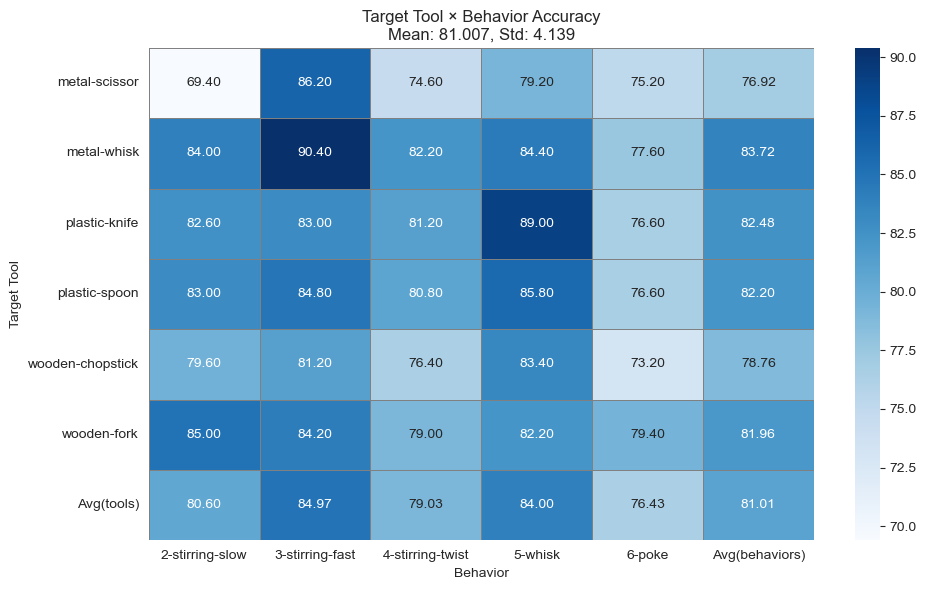

In [20]:
conf_matrix_clap = make_target_behavior_matrix(pair_results_clap)
plot_target_behavior_matrix(df_matrix=conf_matrix_clap*100)

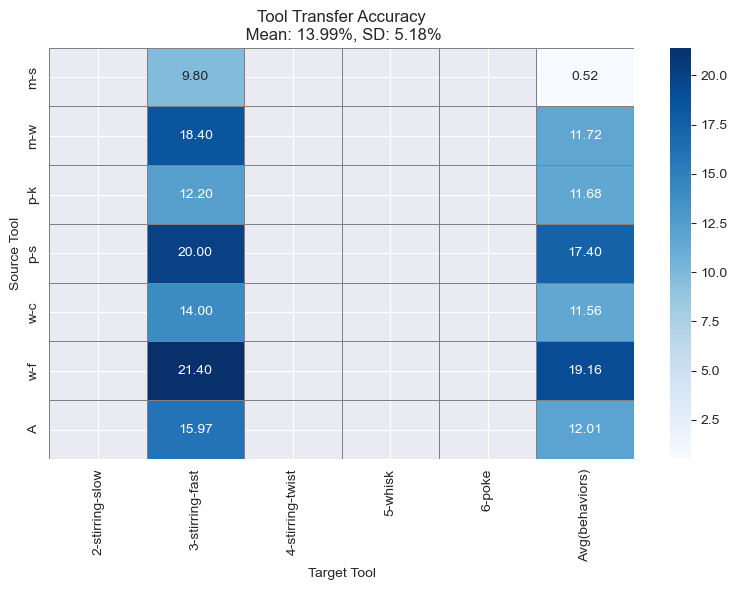

In [21]:
plot_confusion_matrix((conf_matrix_clap - bin_5to1)*100)

### 5to1 vs 1to1

In [22]:
compare_to1_vs_5to1(conf_matrix_clap_to1, conf_matrix_clap, behavior="3-stirring-fast")

{'1-to-1': {'mean': 0.742,
  'std': 0.02734081198501613,
  'per_target': metal-scissor       0.7412
  metal-whisk         0.7876
  plastic-knife       0.7028
  plastic-spoon       0.7452
  wooden-chopstick    0.7436
  wooden-fork         0.7316
  dtype: float64},
 '5-to-1': {'mean': 0.8496666666666667,
  'std': 0.028784640966243703,
  'per_target': target_tool
  metal-scissor       0.862000
  metal-whisk         0.904000
  plastic-knife       0.830000
  plastic-spoon       0.848000
  wooden-chopstick    0.812000
  wooden-fork         0.842000
  Avg(tools)          0.849667
  Name: 3-stirring-fast, dtype: float64}}

In [23]:
df_diff = diff_5to1_minus_1to1(conf_matrix_clap_to1*100, conf_matrix_clap*100, behavior="3-stirring-fast")
print(df_diff)

                  1-to-1  5-to-1  diff (5to1-1to1)
metal-scissor      74.12    86.2             12.08
metal-whisk        78.76    90.4             11.64
plastic-knife      70.28    83.0             12.72
plastic-spoon      74.52    84.8             10.28
wooden-chopstick   74.36    81.2              6.84
wooden-fork        73.16    84.2             11.04


# cross beh

In [24]:
data_name = "audio_20s_clap_emb_all.npz"

context_dict = {
    "source_tool_list": [],
    "target_tool_list": [],
    "source_beh_list": [],
    "target_beh_list": [],
    "test_object_list": [],
    "shared_object_list": [],
}

pair_results_clap_cB = {}
for tgt_b in configs.ALL_BEH_LIST:
    src_b_list = sorted(b for b in configs.ALL_BEH_LIST if b != tgt_b)
    context_dict['source_beh_list'] = src_b_list
    context_dict['target_beh_list'] = [tgt_b]
    for tool in configs.ALL_TOOL_LIST:
        context_dict['source_tool_list'] = [tool]
        context_dict['target_tool_list'] = [tool]
        test_result_dir = get_result_dir(base_dir=base_dir, context_dict=context_dict, 
                                         transfer_type=transfer_type,
                                         modality="audio", data_name=data_name)
    
        try:
            result = load_json(os.path.join(test_result_dir, "results1.json")) 
            pair_results_clap_cB[f"source_{tgt_b}&{tool}"] = result
            # print(f"pair_exist: source_{tgt_t}&{beh}")
        except FileNotFoundError:
            print(f"no result: {test_result_dir}")
            continue  

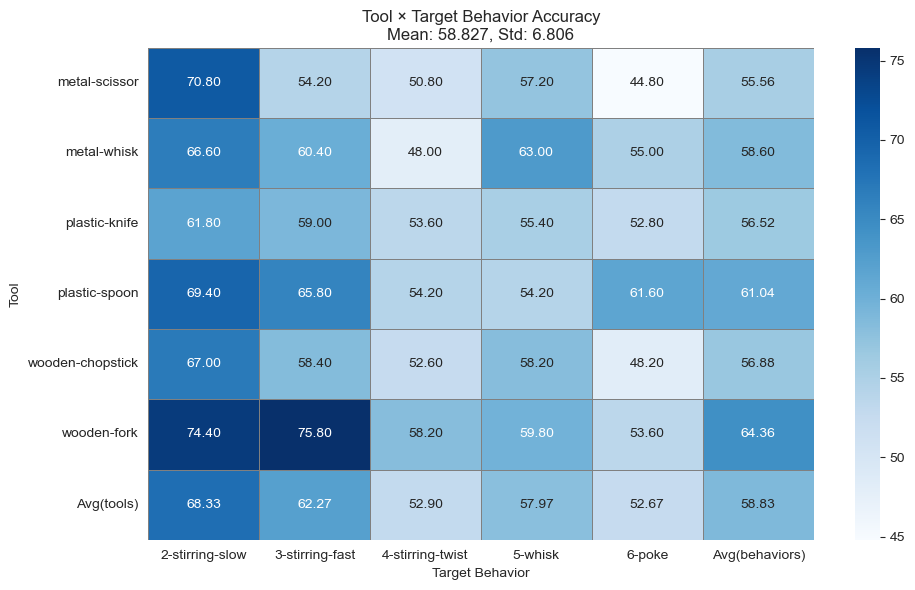

In [27]:
cm_cB_5to1 = make_tool_behavior_matrix(pair_results_clap_cB)
plot_tool_behavior_matrix(cm_cB_5to1*100)